# 📊 Rental Data Exploratory Data Analysis (EDA)

## 🎯 Objective

In this section, I analyse the rental dataset to prepare it for:

- Yield calculations
- Cash flow modeling
- Suburb-level investment insights

This dataset represents the **income side of property investment**, which will later be merged with the sales dataset.

## 🔑 Key Financial Variable

👉 `monthly_rent`

This is the core income variable used for:

- Gross yield
- Net yield
- Cash flow



# 1) Import and setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


sns.set_style("whitegrid")

In [3]:
df_rentals = pd.read_csv("data\processed\expanded_rentals_data.csv")

print("Shape:", df_rentals.shape)
df_rentals.head()

Shape: (10000, 27)


,source_site,listing_id,rental_url,title,monthly_rent,suburb,city,province,property_type,bedrooms,bathrooms,parking_spaces,garage,floor_area_sqm,land_area_sqm,levies,rates_taxes,furnished_flag,availability_text,description,listing_date,scraped_timestamp,pp_transaction_slug,pp_province_slug,pp_metro_slug,pp_city_slug,pp_suburb_slug
0,privateproperty,RR4560077,https://www.privateproperty.co.za/to-rent/gaut...,1 Bedroom Apartment in Noordwyk,4500.0,Noordwyk,Midrand,Gauteng,Apartment,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,"1 Bedroom Apartment in Noordwyk, 73 Riverwalk,...",26 Mar 2026,2026-03-27T17:37:35.113654+00:00,to-rent,gauteng,johannesburg-metro,midrand,noordwyk
1,privateproperty,RR4016373,https://www.privateproperty.co.za/to-rent/gaut...,2 Bedroom Apartment in Klipspruit,6500.0,Pimville,Soweto,Gauteng,Apartment,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2 Bedroom Apartment in Klipspruit, Step into c...",26 Mar 2026,2026-03-27T17:37:31.863821+00:00,to-rent,gauteng,johannesburg-metro,soweto,pimville
2,privateproperty,RR4639578,https://www.privateproperty.co.za/to-rent/gaut...,3 Bedroom Apartment in Waverley,16000.0,Waverley,Rosebank And Parktown,Gauteng,Apartment,3.0,2.0,2.0,NaN,92.0,NaN,NaN,NaN,NaN,Available Now,"3 Bedroom Apartment in Waverley, The Gold Stan...",26 Mar 2026,2026-03-27T17:37:27.750354+00:00,to-rent,gauteng,johannesburg-metro,rosebank-and-parktown,waverley
3,privateproperty,RR4639617,https://www.privateproperty.co.za/to-rent/gaut...,Studio Apartment in Johannesburg CBD,3700.0,Johannesburg Cbd,Johannesburg Central,Gauteng,Apartment,0.5,1.0,NaN,NaN,33.0,NaN,NaN,NaN,NaN,Available Now,"Studio Apartment in Johannesburg CBD, 1604 She...",26 Mar 2026,2026-03-27T17:37:25.147375+00:00,to-rent,gauteng,johannesburg-metro,johannesburg-central,johannesburg-cbd
4,privateproperty,RR4639622,https://www.privateproperty.co.za/to-rent/gaut...,1 Bedroom Apartment in Waterfall Estate,8500.0,Waterfall Estate,Midrand,Gauteng,Apartment,1.0,1.0,1.0,NaN,37.0,NaN,NaN,NaN,0.0,Available Now,"1 Bedroom Apartment in Waterfall Estate, This ...",26 Mar 2026,2026-03-27T17:37:21.446463+00:00,to-rent,gauteng,johannesburg-metro,midrand,waterfall-estate


In [6]:
df_rentals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   source_site          10000 non-null  object 
 1   listing_id           10000 non-null  object 
 2   rental_url           10000 non-null  object 
 3   title                10000 non-null  object 
 4   monthly_rent         10000 non-null  float64
 5   suburb               10000 non-null  object 
 6   city                 10000 non-null  object 
 7   province             10000 non-null  object 
 8   property_type        9962 non-null   object 
 9   bedrooms             10000 non-null  float64
 10  bathrooms            10000 non-null  float64
 11  parking_spaces       9782 non-null   float64
 12  garage               9373 non-null   float64
 13  floor_area_sqm       9510 non-null   float64
 14  land_area_sqm        9313 non-null   float64
 15  levies               0 non-null      

# 2 Exploratory Data Analysis (EDA)

## 2.1 Rental Distribution

Understanding how rent is distributed helps detect:

- skewness
- outliers
- unrealistic values

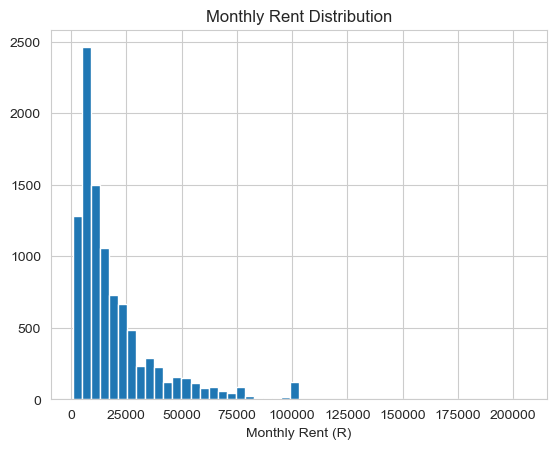

In [7]:
df_rentals["monthly_rent"].hist(bins=50)
plt.title("Monthly Rent Distribution")
plt.xlabel("Monthly Rent (R)")
plt.show()

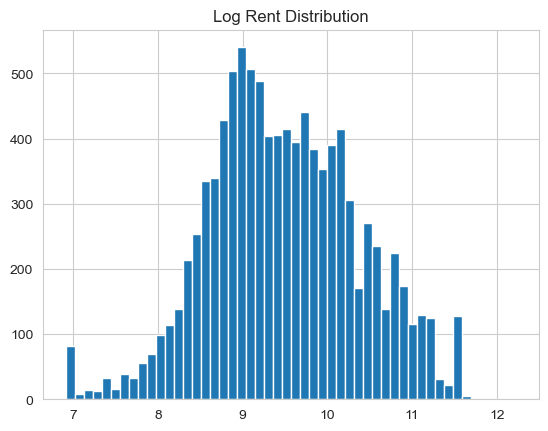

In [8]:
# Log distribution
df_rentals["log_rent"] = np.log1p(df_rentals["monthly_rent"])

df_rentals["log_rent"].hist(bins=50)
plt.title("Log Rent Distribution")
plt.show()

## 2.2) Rent per Suburb

This is one of the most important analyses for investment.

It directly feeds into:

👉 Yield calculations  
👉 Area investment scoring  

In [9]:
suburb_rent_summary = (
    df_rentals.groupby("suburb")
              .agg(
                  listings=("monthly_rent", "count"),
                  avg_rent=("monthly_rent", "mean"),
                  median_rent=("monthly_rent", "median")
              )
              .sort_values("avg_rent", ascending=False)
)

suburb_rent_summary.head(20)

,listings,avg_rent,median_rent
suburb,,,
Steyn City,10,102000.000000,100000.0
Helderfontein Estate,30,67681.666667,78300.0
Fourways Gardens,47,63610.638298,51200.0
Waterfall Country Village,34,61164.705882,66250.0
Hyde Park,218,57446.788991,53100.0
Dainfern Valley,69,52742.753623,53300.0
Sandhurst,23,50052.173913,20600.0
Benmore Gardens,69,49713.043478,73000.0
Cedar Lakes,17,45535.294118,47300.0


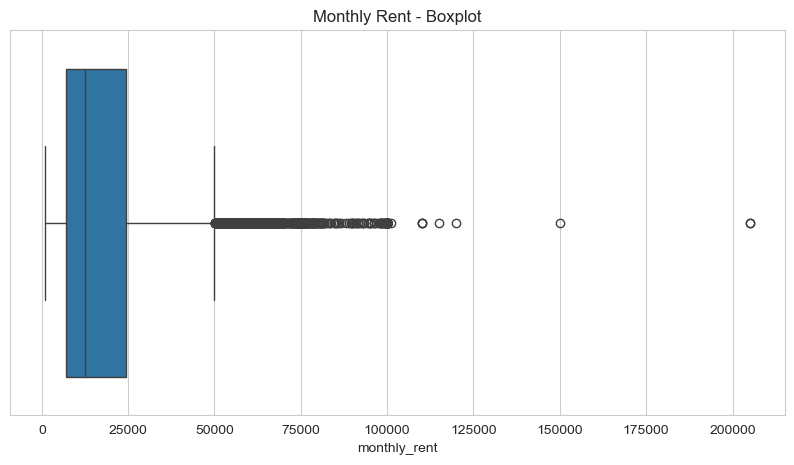

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_rentals["monthly_rent"])
plt.title("Monthly Rent - Boxplot")
plt.show()

In [13]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return lower, upper
lower_rent, upper_rent = detect_outliers_iqr(df_rentals["monthly_rent"])

print("Lower bound:", lower_rent)
print("Upper bound:", upper_rent)

outliers_rent = df_rentals[
    (df_rentals["monthly_rent"] < lower_rent) |
    (df_rentals["monthly_rent"] > upper_rent)
]

print("Outliers count:", len(outliers_rent))
outliers_rent.head()

Lower bound: -18575.0
Upper bound: 50025.0
Outliers count: 792


,source_site,listing_id,rental_url,title,monthly_rent,suburb,city,province,property_type,bedrooms,bathrooms,parking_spaces,garage,floor_area_sqm,land_area_sqm,levies,rates_taxes,furnished_flag,availability_text,description,listing_date,scraped_timestamp,pp_transaction_slug,pp_province_slug,pp_metro_slug,pp_city_slug,pp_suburb_slug,log_rent
132,privateproperty,RR4640602,https://www.privateproperty.co.za/to-rent/gaut...,2 Bedroom Apartment in Sandton Central,60000.0,Sandton Central,Sandton,Gauteng,Apartment,2.0,2.5,1.0,NaN,160.0,NaN,NaN,NaN,1.0,Available 1 July 2026,"2 Bedroom Apartment in Sandton Central, 2 Bedr...",27 Mar 2026,2026-03-27T17:29:32.658432+00:00,to-rent,gauteng,johannesburg-metro,sandton,sandton-central,11.002117
134,privateproperty,RR4640626,https://www.privateproperty.co.za/to-rent/gaut...,3 Bedroom Penthouse in Houghton Estate,58000.0,Houghton Estate,Rosebank And Parktown,Gauteng,House,3.0,3.5,4.0,NaN,355.0,NaN,NaN,NaN,NaN,Available Now,"3 Bedroom Penthouse in Houghton Estate, LIVE L...",27 Mar 2026,2026-03-27T17:29:25.832883+00:00,to-rent,gauteng,johannesburg-metro,rosebank-and-parktown,houghton-estate,10.968216
270,privateproperty,RR3555114,https://www.privateproperty.co.za/to-rent/gaut...,2 Bedroom Apartment in Sandown,101000.0,Sandown,Sandton,Gauteng,Apartment,2.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,1.0,Available Now,"2 Bedroom Apartment in Sandown, 128 The Leonar...",19 Jan 2026,2026-03-27T17:21:05.049131+00:00,to-rent,gauteng,johannesburg-metro,sandton,sandown,11.522886
343,privateproperty,RR4633276,https://www.privateproperty.co.za/to-rent/gaut...,3 Bedroom Apartment in Sandown,65000.0,Sandown,Sandton,Gauteng,Apartment,3.0,3.5,NaN,NaN,274.0,NaN,NaN,NaN,1.0,NaN,"3 Bedroom Apartment in Sandown, 11000 Metropol...",17 Mar 2026,2026-03-27T17:16:22.929521+00:00,to-rent,gauteng,johannesburg-metro,sandton,sandown,11.082158
417,privateproperty,RR4620117,https://www.privateproperty.co.za/to-rent/gaut...,5 Bedroom House in Dainfern Golf Estate,75000.0,Dainfern,Sandton,Gauteng,House,5.0,4.0,NaN,NaN,558.0,1.0,NaN,NaN,NaN,Available Now,"5 Bedroom House in Dainfern Golf Estate, Styli...",2 Mar 2026,2026-03-27T17:11:42.840484+00:00,to-rent,gauteng,johannesburg-metro,sandton,dainfern,11.225257


### 2.3 Remove Outliers

Best when:
- data is noisy
- many scraping errors
- focus is on typical investment properties

In [15]:
df_rentals_clean = df_rentals[
    (df_rentals["monthly_rent"] >= lower_rent) &
    (df_rentals["monthly_rent"] <= upper_rent)
].copy()

print("Before:", df_rentals.shape)
print("After :", df_rentals_clean.shape)

Before: (10000, 28)
After : (9208, 28)


In [19]:
def cap_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return series.clip(lower, upper)

df_rentals["monthly_rent_capped"] = cap_outliers(df_rentals["monthly_rent"])

comparison_rent = pd.DataFrame({
    "original": df_rentals["monthly_rent"].describe(),
    "capped": df_rentals["monthly_rent_capped"].describe()
})

comparison_rent

,original,capped
count,10000.000000,10000.000000
mean,19322.040600,17698.120600
std,19030.581946,14144.219896
min,1000.000000,1000.000000
25%,7150.000000,7150.000000
50%,12400.000000,12400.000000
75%,24300.000000,24300.000000
max,205000.000000,50025.000000


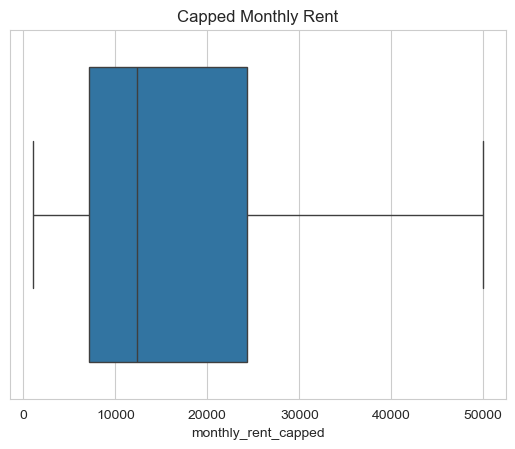

In [20]:
sns.boxplot(x=df_rentals["monthly_rent_capped"])
plt.title("Capped Monthly Rent")
plt.show()

In [21]:
df_rentals.to_csv("data/processed/eda_ready_rentals_data.csv", index=False)

print("✅ Rental dataset ready for Financial Engine")

✅ Rental dataset ready for Financial Engine
